# 04 — Walk-forward GBM (Case B)

Expanding-window global `HistGradientBoostingRegressor`:

- train on `date < t`, score `date == t` for each Tuesday `t ≥ 2025-01-07`
- features via `LaneWeekFeatureBuilder` (lagged RPM + `availability_lag_1`; no same-week availability / rate bands)
- **residual target:** learn `delta = rpm − rpm_lag_1`, then `pred = rpm_lag_1 + deltâ`
- baseline = `rpm_lag_1`

Prefer the reproducible script for full runs:

```bash
python scripts/train_walkforward_gbm.py
```

This notebook loads saved metrics (or re-runs) and plots weekly MAE, actual vs predicted RPM, and lane×time error heatmaps.

In [21]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from freight_rates.ingestion import load_raw_snapshot
from freight_rates.preprocessing import build_lane_week_panel
from freight_rates.splits import filter_model_window
from freight_rates.walkforward import run_walkforward_gbm, save_walkforward_outputs

ROOT = Path("..").resolve()
OUT = ROOT / "models" / "walkforward_gbm"
PRED_PATH = OUT / "walkforward_gbm_predictions.parquet"
WEEK_PATH = OUT / "walkforward_gbm_metrics_by_week.csv"
HIST_PATH = OUT / "walkforward_gbm_metrics_by_history.csv"
OVERALL_PATH = OUT / "walkforward_gbm_metrics_overall.csv"

In [22]:
need_rerun = True
if PRED_PATH.exists() and WEEK_PATH.exists():
    preds = pd.read_parquet(PRED_PATH)
    # Re-run if artifacts predate residual targeting (missing delta_hat).
    need_rerun = "delta_hat" not in preds.columns

if not need_rerun:
    by_week = pd.read_csv(WEEK_PATH, parse_dates=["date"])
    by_history = pd.read_csv(HIST_PATH)
    overall = pd.read_csv(OVERALL_PATH)
    print("Loaded saved walk-forward outputs from", OUT)
else:
    print("Running walk-forward with residual target (may take a few minutes)...")
    panel = filter_model_window(build_lane_week_panel(load_raw_snapshot(raw_dir=ROOT / "data" / "raw")))
    result = run_walkforward_gbm(panel, residual_target=True, verbose=True)
    save_walkforward_outputs(result, OUT)
    preds, by_week, by_history, overall = (
        result.predictions,
        result.by_week,
        result.by_history,
        result.overall,
    )

display(overall)
display(by_history)

Loaded saved walk-forward outputs from /Users/angel/Documents/freight_rate/models/walkforward_gbm


,n,mae,medae,mape,mae_baseline,medae_baseline,mae_lift
0,5689,0.144797,0.03693,4.225159,0.139284,0.016667,-0.005514


,history_bucket,n,mae,medae,mape,mae_baseline,medae_baseline,mae_lift
0,0-4,246,0.376404,0.162623,11.091166,0.406777,0.188696,0.030373
1,5-19,593,0.189223,0.055980,5.360424,0.186153,0.052632,-0.003071
2,20-99,4613,0.128128,0.024631,3.762698,0.120386,0.000000,-0.007742
3,100+,237,0.117695,0.073040,3.259277,0.112180,0.062016,-0.005515


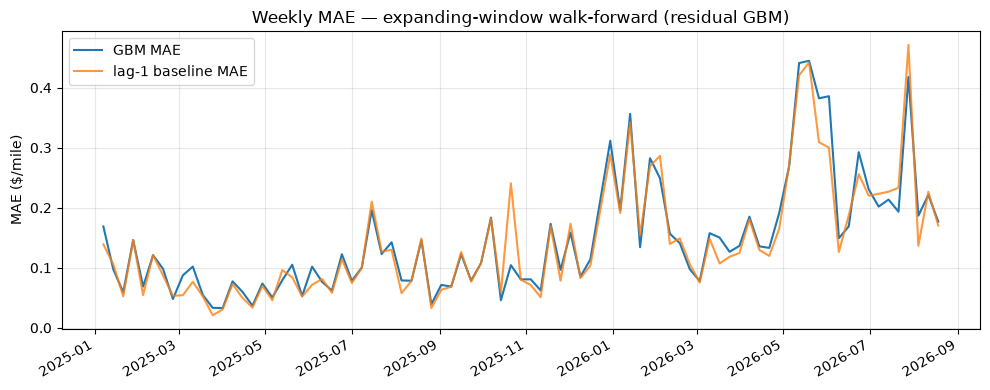

scored rows: 5,689


In [23]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(by_week["date"], by_week["mae"], label="GBM MAE")
if "mae_baseline" in by_week.columns:
    ax.plot(by_week["date"], by_week["mae_baseline"], label="lag-1 baseline MAE", alpha=0.8)
ax.set_title("Weekly MAE — expanding-window walk-forward (residual GBM)")
ax.set_ylabel("MAE ($/mile)")
ax.legend()
ax.grid(True, alpha=0.3)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

print(f"scored rows: {len(preds):,}")

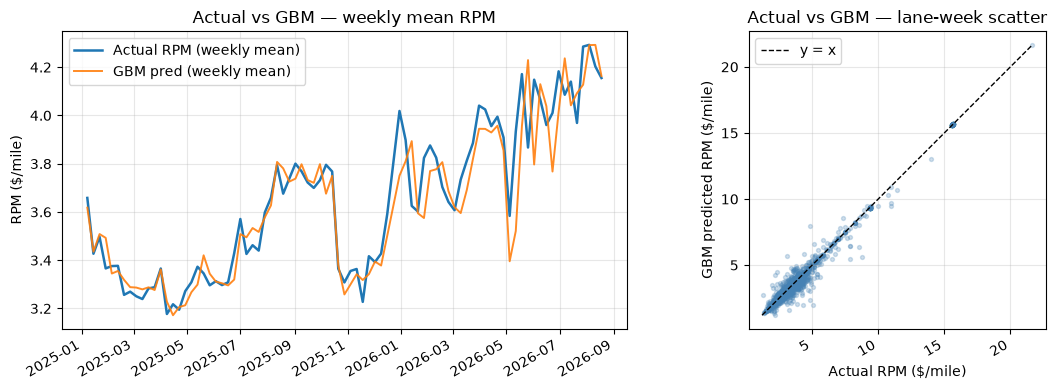

,date,rpm_true,rpm_gbm,rpm_lag1,n
0,2025-01-07,3.658201,3.617985,3.667572,89
1,2025-01-14,3.426901,3.435319,3.509720,89
2,2025-01-21,3.496844,3.508420,3.507820,79
3,2025-01-28,3.366109,3.492680,3.496844,79
4,2025-02-04,3.375722,3.344832,3.366109,79


In [24]:
# Actual vs GBM predicted RPM (weekly mean across lanes), plus scatter.
weekly_levels = (
    preds.groupby("date", as_index=False)
    .agg(
        rpm_true=("y_true", "mean"),
        rpm_gbm=("y_pred", "mean"),
        rpm_lag1=("y_pred_baseline", "mean"),
        n=("y_true", "size"),
    )
    .sort_values("date")
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(weekly_levels["date"], weekly_levels["rpm_true"], label="Actual RPM (weekly mean)", lw=1.8)
axes[0].plot(weekly_levels["date"], weekly_levels["rpm_gbm"], label="GBM pred (weekly mean)", lw=1.4, alpha=0.9)
axes[0].set_title("Actual vs GBM — weekly mean RPM")
axes[0].set_ylabel("RPM ($/mile)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)
fig.autofmt_xdate()

# Subsample for readability if many points
scatter = preds.sample(n=min(2500, len(preds)), random_state=42)
axes[1].scatter(scatter["y_true"], scatter["y_pred"], s=8, alpha=0.25, color="steelblue")
lims = [
    min(scatter["y_true"].min(), scatter["y_pred"].min()),
    max(scatter["y_true"].max(), scatter["y_pred"].max()),
]
axes[1].plot(lims, lims, color="black", lw=1, ls="--", label="y = x")
axes[1].set_xlabel("Actual RPM ($/mile)")
axes[1].set_ylabel("GBM predicted RPM ($/mile)")
axes[1].set_title("Actual vs GBM — lane-week scatter")
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_aspect("equal", adjustable="box")

plt.tight_layout()
plt.show()

weekly_levels.head()


## Error heatmaps — which lanes / months hurt most

Absolute error `|y_true − y_pred|` by **lane × month** (lanes with ≥10 scored weeks) and **lane × week** for the worst 30. Rows sorted by overall lane MAE so high-error corridors sit at the top; empty cells are weeks with no observation for that lane.


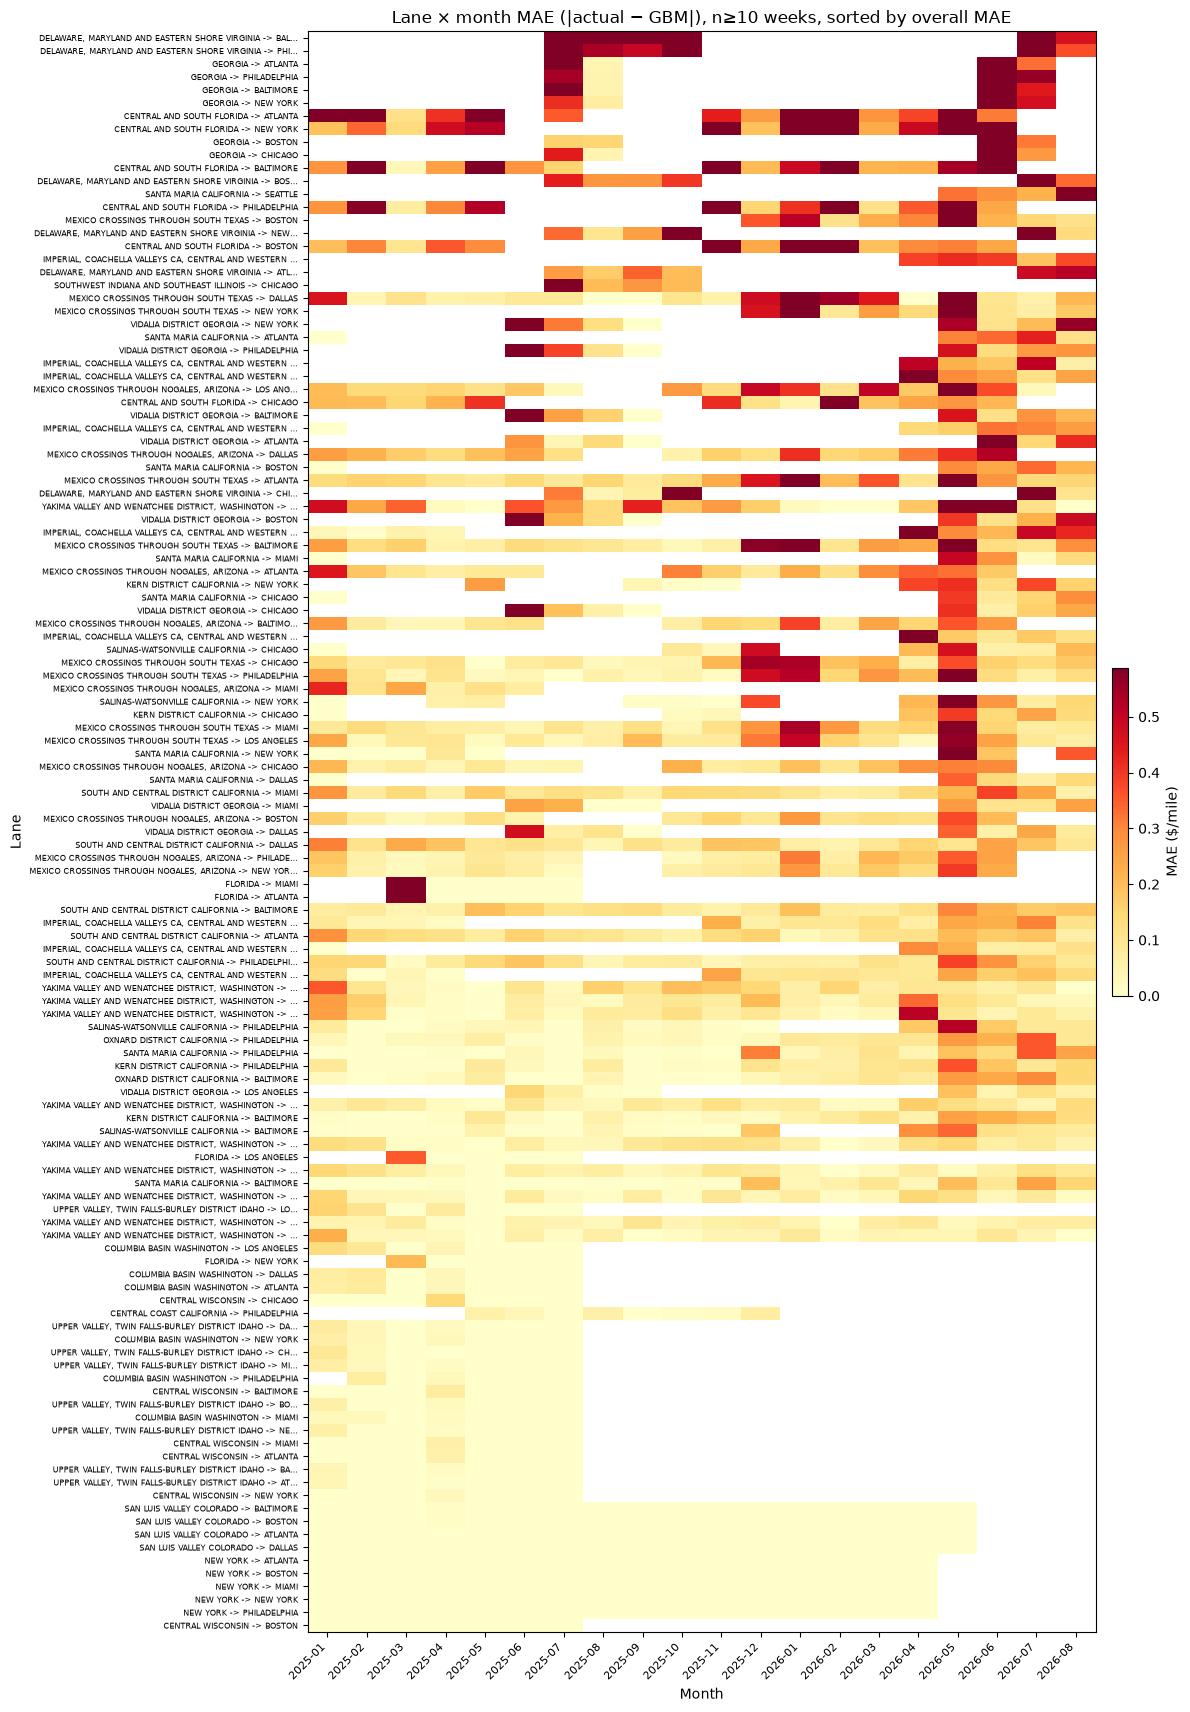

Worst lanes by overall MAE (n≥10):


,lane_id,mae,n
0,"DELAWARE, MARYLAND AND EASTERN SHORE VIRGINIA ...",1.101436,16
1,"DELAWARE, MARYLAND AND EASTERN SHORE VIRGINIA ...",0.783304,16
2,GEORGIA -> ATLANTA,0.750673,10
3,GEORGIA -> PHILADELPHIA,0.741339,10
4,GEORGIA -> BALTIMORE,0.692766,10
5,GEORGIA -> NEW YORK,0.644473,10
6,CENTRAL AND SOUTH FLORIDA -> ATLANTA,0.543780,51
7,CENTRAL AND SOUTH FLORIDA -> NEW YORK,0.518627,50
8,GEORGIA -> BOSTON,0.473568,10
9,GEORGIA -> CHICAGO,0.472889,10


Worst lanes including sparse (any n):


,lane_id,mae,n
0,NORTH CAROLINA -> BALTIMORE,1.164461,4
1,CENTRAL AND NORTH FLORIDA -> BALTIMORE,1.144380,1
2,"DELAWARE, MARYLAND AND EASTERN SHORE VIRGINIA ...",1.101436,16
3,NORTH CAROLINA -> NEW YORK,0.907782,4
4,"DELAWARE, MARYLAND AND EASTERN SHORE VIRGINIA ...",0.783304,16
5,GEORGIA -> ATLANTA,0.750673,10
6,GEORGIA -> PHILADELPHIA,0.741339,10
7,GEORGIA -> BALTIMORE,0.692766,10
8,NORTH CAROLINA -> BOSTON,0.678813,4
9,NORTH CAROLINA -> PHILADELPHIA,0.646771,4


In [25]:
import numpy as np

err = preds.copy()
err["date"] = pd.to_datetime(err["date"])
err["abs_err"] = (err["y_true"] - err["y_pred"]).abs()
err["month"] = err["date"].dt.to_period("M").astype(str)

lane_mae = (
    err.groupby("lane_id", as_index=False)
    .agg(mae=("abs_err", "mean"), n=("abs_err", "size"))
    .sort_values(["mae", "n"], ascending=[False, False])
    .reset_index(drop=True)
)

# Prefer lanes with enough scored weeks so outliers with 1–4 obs do not dominate.
MIN_WEEKS = 10
lane_mae_stable = (
    lane_mae.loc[lane_mae["n"] >= MIN_WEEKS]
    .sort_values(["mae", "n"], ascending=[False, False])
    .reset_index(drop=True)
)

# Monthly MAE: lanes (Y) × calendar month (X)
month_pivot = (
    err.groupby(["lane_id", "month"])["abs_err"]
    .mean()
    .unstack("month")
    .reindex(index=lane_mae_stable["lane_id"], columns=sorted(err["month"].unique()))
)

short_lane = [
    (lid[:52] + "…" if len(lid) > 52 else lid) for lid in month_pivot.index
]
vmax = float(np.nanpercentile(month_pivot.to_numpy(dtype=float), 95))

fig, ax = plt.subplots(figsize=(12, max(8, 0.14 * len(month_pivot))))
im = ax.imshow(
    month_pivot.to_numpy(dtype=float),
    aspect="auto",
    cmap="YlOrRd",
    vmin=0.0,
    vmax=vmax,
    interpolation="nearest",
)
ax.set_xticks(range(len(month_pivot.columns)))
ax.set_xticklabels(month_pivot.columns, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(len(month_pivot.index)))
ax.set_yticklabels(short_lane, fontsize=6)
ax.set_title(
    f"Lane × month MAE (|actual − GBM|), n≥{MIN_WEEKS} weeks, sorted by overall MAE"
)
ax.set_xlabel("Month")
ax.set_ylabel("Lane")
cbar = plt.colorbar(im, ax=ax, fraction=0.02, pad=0.02)
cbar.set_label("MAE ($/mile)")
plt.tight_layout()
plt.show()

print(f"Worst lanes by overall MAE (n≥{MIN_WEEKS}):")
display(lane_mae_stable.head(15))
print("Worst lanes including sparse (any n):")
display(lane_mae.head(10))


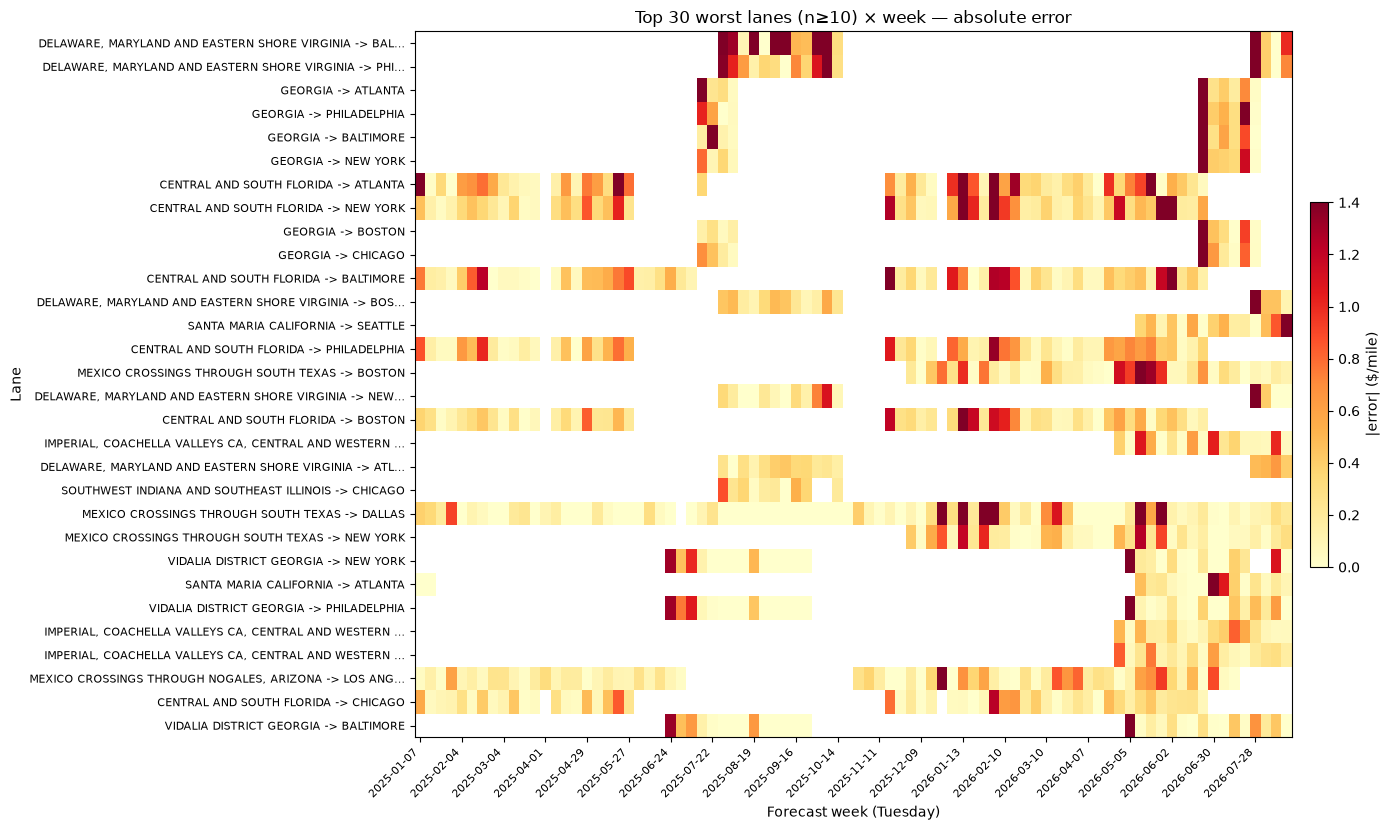

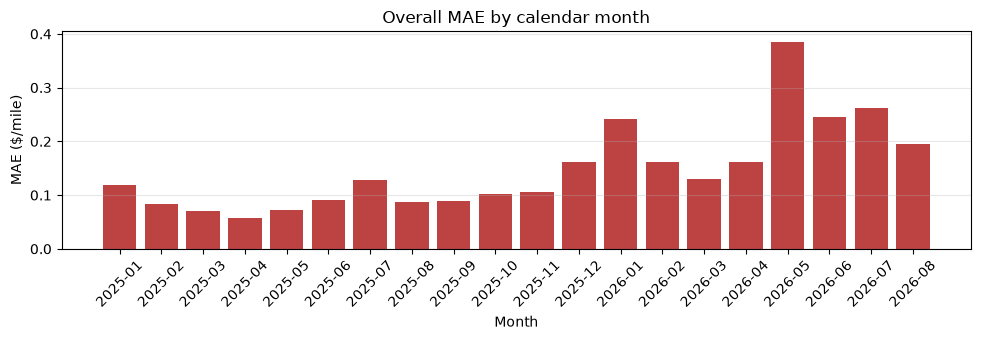

,month,mae,n
16,2026-05,0.385514,293
18,2026-07,0.262186,276
17,2026-06,0.245813,376
12,2026-01,0.242310,220
19,2026-08,0.195226,216
15,2026-04,0.161860,247
11,2025-12,0.161503,224
13,2026-02,0.161227,220


In [26]:
# Weekly absolute error for the worst TOP_N stable lanes (finer time grain).
TOP_N = 30
worst_lanes = lane_mae_stable.head(TOP_N)["lane_id"].tolist()
week_labels = sorted(err["date"].unique())
week_pivot = (
    err.loc[err["lane_id"].isin(worst_lanes)]
    .groupby(["lane_id", "date"])["abs_err"]
    .mean()
    .unstack("date")
    .reindex(index=worst_lanes, columns=week_labels)
)

short_worst = [
    (lid[:52] + "…" if len(lid) > 52 else lid) for lid in week_pivot.index
]
vmax_w = float(np.nanpercentile(week_pivot.to_numpy(dtype=float), 95))

fig, ax = plt.subplots(figsize=(14, max(6, 0.28 * TOP_N)))
im = ax.imshow(
    week_pivot.to_numpy(dtype=float),
    aspect="auto",
    cmap="YlOrRd",
    vmin=0.0,
    vmax=vmax_w,
    interpolation="nearest",
)
tick_idx = list(range(0, len(week_labels), 4))
ax.set_xticks(tick_idx)
ax.set_xticklabels(
    [pd.Timestamp(week_labels[i]).strftime("%Y-%m-%d") for i in tick_idx],
    rotation=45,
    ha="right",
    fontsize=8,
)
ax.set_yticks(range(len(week_pivot.index)))
ax.set_yticklabels(short_worst, fontsize=8)
ax.set_title(f"Top {TOP_N} worst lanes (n≥{MIN_WEEKS}) × week — absolute error")
ax.set_xlabel("Forecast week (Tuesday)")
ax.set_ylabel("Lane")
cbar = plt.colorbar(im, ax=ax, fraction=0.02, pad=0.02)
cbar.set_label("|error| ($/mile)")
plt.tight_layout()
plt.show()

# Month-level MAE across all lanes (when the model struggles globally)
by_month = (
    err.groupby("month", as_index=False)
    .agg(mae=("abs_err", "mean"), n=("abs_err", "size"))
    .sort_values("month")
)
fig, ax = plt.subplots(figsize=(10, 3.5))
ax.bar(by_month["month"], by_month["mae"], color="firebrick", alpha=0.85)
ax.set_title("Overall MAE by calendar month")
ax.set_ylabel("MAE ($/mile)")
ax.set_xlabel("Month")
ax.tick_params(axis="x", rotation=45)
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()
display(by_month.sort_values("mae", ascending=False).head(8))
